In [ ]:
# AND gate, OR gate에 대해서
# Perceptron으로 구현해보아요!
# => AND , OR gate의 진리표를 이용해서 Logistic Regression을 구현

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD
from sklearn import linear_model
from sklearn.metrics import classification_report

# 학습데이터
x_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# AND GATE에 대한 학습데이터 => OK 학습이 가능해요!
# t_data = np.array([[0], [0], [0], [1]])
# OR GATE에 대한 학습데이터 => OK 학습이 가능해요!
# t_data = np.array([[0], [1], [1], [1]])
# XOR GATE에 대한 학습데이터 =>
t_data = np.array([[0], [1], [1], [0]])

keras_model = Sequential()
keras_model.add(Flatten(input_shape=(2,)))

keras_model.add(Dense(units=64,
                      activation='relu'))
keras_model.add(Dense(units=128,
                      activation='relu'))

keras_model.add(Dense(units=1,
                      activation='sigmoid'))
keras_model.compile(optimizer=SGD(learning_rate=1e-1),
                    loss='binary_crossentropy',
                    metrics=['acc'])
keras_model.summary()
keras_model.fit(x_data,
                t_data,
                epochs=1000,
                verbose=1)



In [19]:
print(keras_model.predict(np.array([[0, 0]])))
# [[0.00823041]] => 0
print(keras_model.predict(np.array([[0, 1]])))
# [[0.15083914]] => 0
print(keras_model.predict(np.array([[1, 0]])))
# [[0.14734001]] => 0
print(keras_model.predict(np.array([[1, 1]])))
# [[0.78717864]] => 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[[0.00652733]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.9985482]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.9984154]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.00101653]]


In [20]:
# MNIST 예제로 DNN을 구현해 보아요!
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [22]:
# 필요한 module import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
# 1. 결측치 - 없어요!
# 2. 이상치 - 없어요!
# 3. 정규화 - MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
# 4. 데이터 분리
from sklearn.model_selection import train_test_split
# 5. 데이터의 불균형

# Model 구현
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

# 성능평가
from sklearn.metrics import classification_report

In [ ]:
# 1. Raw Data Loading
df = pd.read_csv('/content/train.csv')
# display(df.head(), df.shape) # (42000, 785)

In [30]:
# 2. Feature Engineering & 데이터 전처리
# Feature Engineering : 수행할 작업이 없어요!
# 데이터 전처리
# 1. 결측치 없구요.
# 2. 이상치 없구요.
# 3. 정규화
x_data = df.drop('label', axis=1, inplace=False).values
t_data = df['label'].values.reshape(-1,1)
# 우리가 학습해야 할 데이터는 다중분류이기 때문에
# t_data는 one-hot encoding으로 처리해야 해요.
# 하지만 keras설정으로 대신할거예요!

# 이미지 10장만 눈으로 확인해 보아요!
# fig = plt.figure()

# axes = []  # subplot을 10개 만들어서 리스트안에 저장
# for n in range(10):
#     axes.append(fig.add_subplot(2,5,n+1))
#     axes[n].imshow(x_data[n].reshape(28,28),
#                    cmap='gray_r')  # gray_r은 역광
# plt.tight_layout()
# plt.show()

scaler = MinMaxScaler()
scaler.fit(x_data)
x_data_norm = scaler.transform(x_data)

# 4. 데이터 분할
x_data_train_norm, x_data_test_norm, t_data_train, t_data_test = \
train_test_split(x_data_norm,
                 t_data,
                 test_size=0.2,
                 stratify=t_data)

In [41]:
# Model 구현

model = Sequential()

model.add(Flatten(input_shape=(784,)))

model.add(Dense(units=64,
                activation='relu'))
model.add(Dense(units=128,
                activation='relu'))

model.add(Dense(units=10,
                activation='softmax'))
# model.summary()

model.compile(optimizer=SGD(learning_rate=1e-1),
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

# EarlyStopping callback
es_callback = EarlyStopping(monitor='val_loss',
                            patience=5,
                            restore_best_weights=True,
                            verbose=1)

# 저장하는(Checkpoint) callback


In [ ]:
# 학습진행
history = model.fit(x_data_train_norm,
                    t_data_train,
                    epochs=100,
                    batch_size=100,
                    validation_split=0.3,
                    callbacks=[es_callback],
                    verbose=1)

In [ ]:
# 학습 종료 후 그래프 확인
plt.plot(history.history['acc'], color='r')
plt.plot(history.history['val_acc'], color='b')
plt.show()

In [44]:
# Evaluation(성능평가)
print(classification_report(t_data_test,
                            np.argmax(model.predict(x_data_test_norm), axis=1)))

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       827
           1       0.98      0.99      0.99       937
           2       0.96      0.97      0.96       835
           3       0.96      0.95      0.96       870
           4       0.97      0.97      0.97       814
           5       0.97      0.94      0.95       759
           6       0.99      0.97      0.98       827
           7       0.97      0.96      0.96       880
           8       0.94      0.96      0.95       813
           9       0.94      0.95      0.94       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.97      0.96      0.97      8400



In [ ]:
# SVM 구현
# 예제 데이터는 mglearn에 있는 데이터를 사용
# Decision Boundaries를 눈으로 확인해 보아요!
!pip install mglearn

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
from sklearn.svm import SVC   # C => Classifier(분류기)
# decision boundaries는 그리기가 힘들어요!
# 라이브러리를 이용해서 결정경계를 그려볼꺼예요!
from mlxtend.plotting import plot_decision_regions

찾아낸 support vector : [[ 8.1062269   4.28695977]
 [ 8.7337095   2.49162431]
 [11.563957    1.3389402 ]
 [ 8.67494727  4.47573059]
 [10.24028948  2.45544401]
 [ 7.99815287  4.8525051 ]]


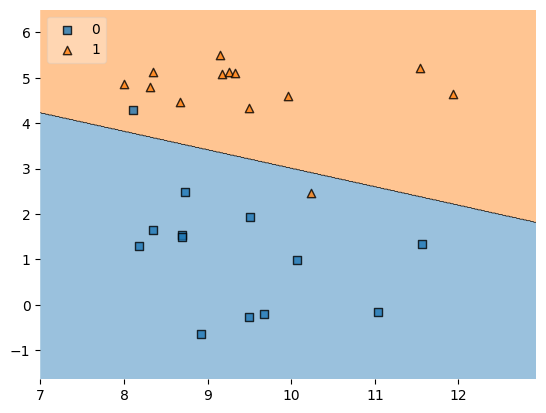

In [58]:
# 데이터부터 가져와요!
x_data, t_data = mglearn.datasets.make_forge()

# matplotlib을 이용해서
# t_data가 0인 점은 red로, t_data가 1인 점은 blue로 표현
# 데이터의 분포를 눈으로 확인하고 싶어요!

x_data_red = x_data[t_data==0]
x_data_blue = x_data[t_data==1]

# plt.scatter(x_data_red[:,0], x_data_red[:,1], color='r')
# plt.scatter(x_data_blue[:,0], x_data_blue[:,1], color='b')


model = SVC(kernel='linear')
model.fit(x_data, t_data)

print(f'찾아낸 support vector : {model.support_vectors_}')
# print(f'찾아낸 support vector의 수 : {model.n_support_}')

plot_decision_regions(X=x_data,
                      y=t_data,
                      clf=model,
                      legend=2)
plt.show()

In [ ]:
# Iris Data Set을 이용해서
# 다중분류를 할 수 있는 머신러닝 모델을 구현하고 정확도를 측정해보세요!
# Logistic Regression을 이용한 다중 분류
# SVM을 이용한 다중 분류
# 정확도를 비교 출력한 후 Decision Boundaries를 그려보세요!

